# Proyecto 3 – Resultados: Modelos de Clasificación

**Integrantes:**  
- Gabriel Bran, 23590  
- David Domínguez, 23712  
- Luis Padilla, 23663  


**Variable respuesta:** `BRECHA_EDAD_ALTA`  
**Tipo de problema:** Clasificación Binaria Supervisada  
**Dataset:** Divorcios en Guatemala (INE, 2011–2021)  


## Descripción General

Este notebook implementa, evalúa y compara tres algoritmos de clasificación supervisada aplicados al dataset de divorcios guatemaltecos. El objetivo es predecir si la diferencia de edad entre los cónyuges es significativa (`BRECHA_EDAD_ALTA = 1` si la brecha supera los 5 años, `0` en caso contrario).


## 1. Importación de Librerías


In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 110
RANDOM_STATE = 42

## 2. Carga y Exploración Inicial del Dataset

In [2]:
# Carga del dataset
df = pd.read_csv("div_full.csv")

print(f"Dimensiones del dataset: {df.shape[0]} filas × {df.shape[1]} columnas")
print()
print("Primeras 5 filas")
df.head()


Dimensiones del dataset: 56349 filas × 12 columnas

Primeras 5 filas


,AÑOREG,DEPOCU,DEPREG,DIAOCU,EDADHOM,EDADMUJ,MESOCU,MESREG,MUPOCU,MUPREG,NACHOM,NACMUJ
0,2011.0,Quetzaltenango,Quetzaltenango,21.0,44.0,14.0,Febrero,Julio,Quetzaltenango,Quetzaltenango,Guatemala,Guatemala
1,2011.0,Guatemala,Guatemala,7.0,Ignorado,Ignorado,Abril,Agosto,Guatemala,Guatemala,Guatemala,Austria
2,2011.0,Guatemala,Guatemala,5.0,Ignorado,Ignorado,Septiembre,Octubre,Guatemala,Guatemala,Guatemala,Bolivia
3,2011.0,Izabal,Izabal,6.0,Ignorado,Ignorado,Julio,Agosto,Puerto Barrios,Puerto Barrios,Guatemala,Canadá
4,2011.0,Guatemala,Guatemala,29.0,Ignorado,Ignorado,Julio,Noviembre,Guatemala,Guatemala,Guatemala,Canadá


In [3]:
# Información general de tipos y nulos aparentes
print("Información de columnas")
df.info()


Información de columnas
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56349 entries, 0 to 56348
Data columns (total 12 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   AÑOREG   56349 non-null  float64
 1   DEPOCU   56349 non-null  object 
 2   DEPREG   56349 non-null  object 
 3   DIAOCU   56349 non-null  float64
 4   EDADHOM  56349 non-null  object 
 5   EDADMUJ  56349 non-null  object 
 6   MESOCU   56349 non-null  object 
 7   MESREG   56349 non-null  object 
 8   MUPOCU   56349 non-null  object 
 9   MUPREG   56349 non-null  object 
 10  NACHOM   56349 non-null  object 
 11  NACMUJ   56349 non-null  object 
dtypes: float64(2), object(10)
memory usage: 5.2+ MB


In [4]:
# Estadísticas descriptivas (columnas numéricas ya convertidas)
print("Descripción general de columnas objeto")
df.describe(include='all')


Descripción general de columnas objeto


,AÑOREG,DEPOCU,DEPREG,DIAOCU,EDADHOM,EDADMUJ,MESOCU,MESREG,MUPOCU,MUPREG,NACHOM,NACMUJ
count,56349.000000,56349,56349,56349.000000,56349,56349,56349,56349,56349,56349,56349,56349
unique,NaN,28,28,NaN,77,67,12,12,331,331,72,55
top,NaN,Guatemala,Guatemala,NaN,Ignorado,Ignorado,Octubre,Octubre,Guatemala,Guatemala,Guatemala,Guatemala
freq,NaN,21694,22339,NaN,30882,30765,5659,5214,15373,17211,55226,55219
mean,2015.934657,NaN,NaN,15.748549,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,2.808174,NaN,NaN,8.696303,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,2011.000000,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,2014.000000,NaN,NaN,8.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,2016.000000,NaN,NaN,16.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,2018.000000,NaN,NaN,23.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
# Revisión de valores únicos especiales en EDADHOM y EDADMUJ
print("Valores únicos en EDADHOM:", df['EDADHOM'].unique()[:15])
print()
print("Valores únicos en EDADMUJ:", df['EDADMUJ'].unique()[:15])


Valores únicos en EDADHOM: ['44.0' 'Ignorado' '36.0' '23.0' '29.0' '30.0' '35.0' '25.0' '56.0' '50.0'
 '31.0' '39.0' '48.0' '41.0' '34.0']

Valores únicos en EDADMUJ: ['14.0' 'Ignorado' '37.0' '29.0' '32.0' '24.0' '23.0' '20.0' '52.0' '25.0'
 '31.0' '54.0' '45.0' '34.0' '36.0']


### Observaciones de la exploración inicial

Con el dataset completo (`div_full.csv`) se observa lo siguiente:

- El dataset contiene **56,349 registros** y **12 columnas** con información geográfica (departamento y municipio de ocurrencia y registro), temporal (año, mes, día) y demográfica (edades, nacionalidades).
- Las columnas `EDADHOM` y `EDADMUJ` son de tipo *objeto* (texto). El valor más frecuente en ambas es `'Ignorado'`, con **30,882** registros sin edad del hombre y **30,765** sin edad de la mujer. Estos valores se tratarán como faltantes.
- Las columnas `NACHOM`, `NACMUJ`, `DEPOCU` y `MESOCU` son categóricas y requerirán codificación One-Hot.
- La columna `DEPOCU` tiene **28 valores únicos** (departamentos), `MESOCU` tiene **12** (meses) y `NACHOM`/`NACMUJ` tienen **72** y **55** nacionalidades únicas respectivamente.
- El año de registro promedio es **2015.9**, cubriendo el período 2011–2021.


## 3. Preprocesamiento (6)

El preprocesamiento es el paso más crítico del pipeline. Se realizan las siguientes transformaciones de forma secuencial:

1. Conversión de edades a tipo numérico (los valores `'Ignorado'` se convierten a `NaN`).
2. Eliminación de registros con edades desconocidas (necesario para calcular la variable respuesta).
3. Ingeniería de características: construcción de `BRECHA` y `BRECHA_EDAD_ALTA`.
4. Selección de columnas relevantes para el modelo.
5. Codificación One-Hot de variables categóricas.
6. Verificación del dataset limpio.


In [6]:
# Paso 1: Convertir edades a numérico
# 'Ignorado' y cualquier texto no numérico se convierte a NaN automáticamente
df['EDADHOM'] = pd.to_numeric(df['EDADHOM'], errors='coerce')
df['EDADMUJ'] = pd.to_numeric(df['EDADMUJ'], errors='coerce')

nulos_antes = df[['EDADHOM', 'EDADMUJ']].isnull().sum()
print("Valores nulos tras conversión:")
print(nulos_antes)
print(f"Total filas originales: {len(df)}")


Valores nulos tras conversión:
EDADHOM    30882
EDADMUJ    30765
dtype: int64
Total filas originales: 56349


In [7]:
# Paso 2: Eliminar filas con edades faltantes
df_clean = df.dropna(subset=['EDADHOM', 'EDADMUJ']).copy()
print(f"Filas después de eliminar nulos en edades: {len(df_clean)}")
print(f"Filas eliminadas: {len(df) - len(df_clean)} ({(len(df)-len(df_clean))/len(df)*100:.1f}%)")


Filas después de eliminar nulos en edades: 23297
Filas eliminadas: 33052 (58.7%)


In [8]:
# Paso 3: Ingeniería de características – Variable Respuesta
df_clean['BRECHA'] = (df_clean['EDADHOM'] - df_clean['EDADMUJ']).abs()
df_clean['BRECHA_EDAD_ALTA'] = (df_clean['BRECHA'] > 5).astype(int)

print("Distribución de BRECHA_EDAD_ALTA:")
conteo = df_clean['BRECHA_EDAD_ALTA'].value_counts()
prop   = df_clean['BRECHA_EDAD_ALTA'].value_counts(normalize=True) * 100
resumen = pd.DataFrame({'Conteo': conteo, 'Porcentaje (%)': prop.round(2)})
resumen.index = ['Brecha ≤ 5 años (0)', 'Brecha > 5 años (1)']
print(resumen)


Distribución de BRECHA_EDAD_ALTA:
                     Conteo  Porcentaje (%)
Brecha ≤ 5 años (0)   16247           69.74
Brecha > 5 años (1)    7050           30.26


In [9]:
# Paso 4: Selección de columnas para el modelo
# Se usan variables que aportan información demográfica/geográfica como predictoras.
# Se excluyen: DEPREG, MUPREG (redundante con DEPOCU/MUPOCU), DIAOCU (muy granular).
columnas_modelo = ['AÑOREG', 'DEPOCU', 'MESOCU', 'NACHOM', 'NACMUJ',
                   'EDADHOM', 'EDADMUJ', 'BRECHA_EDAD_ALTA']

df_model = df_clean[columnas_modelo].copy()
print(f"Shape del dataset para modelado: {df_model.shape}")
df_model.head()


Shape del dataset para modelado: (23297, 8)


,AÑOREG,DEPOCU,MESOCU,NACHOM,NACMUJ,EDADHOM,EDADMUJ,BRECHA_EDAD_ALTA
0,2011.0,Quetzaltenango,Febrero,Guatemala,Guatemala,44.0,14.0,1
5,2012.0,Guatemala,Diciembre,El Salvador,Colombia,36.0,37.0,0
8,2012.0,Guatemala,Agosto,Guatemala,Colombia,23.0,29.0,1
13,2011.0,Guatemala,Marzo,Guatemala,Cuba,29.0,32.0,0
14,2012.0,Guatemala,Noviembre,Guatemala,Ecuador,30.0,29.0,0


In [10]:
# Paso 5: One-Hot Encoding para variables categóricas
cat_cols = ['DEPOCU', 'MESOCU', 'NACHOM', 'NACMUJ']
df_encoded = pd.get_dummies(df_model, columns=cat_cols, drop_first=True)

print(f"Columnas tras One-Hot Encoding: {df_encoded.shape[1]}")
print("Primeras columnas:", list(df_encoded.columns[:10]))


Columnas tras One-Hot Encoding: 141
Primeras columnas: ['AÑOREG', 'EDADHOM', 'EDADMUJ', 'BRECHA_EDAD_ALTA', 'DEPOCU_Baja Verapaz', 'DEPOCU_Chimaltenango', 'DEPOCU_Chiquimula', 'DEPOCU_El Progreso', 'DEPOCU_Escuintla', 'DEPOCU_Guatemala']


In [11]:
# Paso 6: Verificación final del dataset limpio
print("¿Valores nulos restantes?", df_encoded.isnull().sum().sum())
print("Tipos de datos:")
print(df_encoded.dtypes.value_counts())
print(f"\nShape final: {df_encoded.shape}")


¿Valores nulos restantes? 0
Tipos de datos:
bool       137
float64      3
int32        1
Name: count, dtype: int64

Shape final: (23297, 141)


### Nota sobre el desbalance de clases

Con el dataset completo se observa un **desbalance moderado**: el 69.74% de los registros corresponden a brecha baja (≤ 5 años, clase 0) y el 30.26% a brecha alta (> 5 años, clase 1). Esto implica que un clasificador trivial que prediga siempre la clase mayoritaria alcanzaría un 69.74% de accuracy, por lo que esta métrica sola no es suficiente para evaluar el desempeño. Se usará **`stratify=y`** al dividir los datos para mantener esta proporción en entrenamiento y prueba, y el **F1-Score** como métrica primaria de comparación.


## 4. Análisis Exploratorio Básico (EDA)

Antes de entrenar los modelos se visualizan las distribuciones de las variables numéricas clave y las correlaciones entre ellas. Esto permite entender la naturaleza de los datos y anticipar el comportamiento de los algoritmos.

> **Nota:** Los árboles de decisión y Random Forest son invariantes a la escala y distribución de las variables. La Regresión Logística, en cambio, asume que las variables numéricas están en una escala comparable, por lo que se aplica `StandardScaler` exclusivamente para ese modelo.


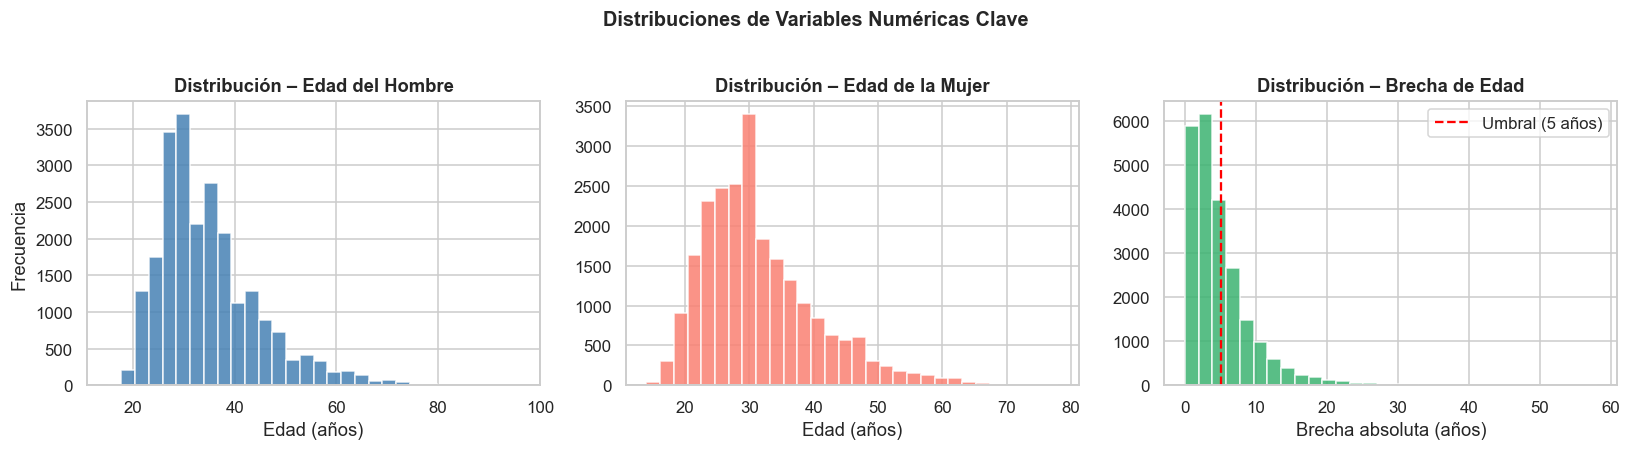

Las distribuciones de edad presentan una forma aproximadamente normal con sesgo hacia edades más jóvenes.
La brecha de edad muestra una distribución sesgada a la derecha con concentración en valores bajos.


In [12]:
# Los árboles de decisión y Random Forest son invariantes a la escala y distribución de las variables. 
# La Regresión Logística, en cambio, asume que las variables numéricas están en una escala comparable, por lo que se aplicará `StandardScaler` exclusivamente para ese modelo.
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(df_clean['EDADHOM'], bins=30, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_title('Distribución – Edad del Hombre', fontweight='bold')
axes[0].set_xlabel('Edad (años)')
axes[0].set_ylabel('Frecuencia')

axes[1].hist(df_clean['EDADMUJ'], bins=30, color='salmon', edgecolor='white', alpha=0.85)
axes[1].set_title('Distribución – Edad de la Mujer', fontweight='bold')
axes[1].set_xlabel('Edad (años)')

axes[2].hist(df_clean['BRECHA'], bins=30, color='mediumseagreen', edgecolor='white', alpha=0.85)
axes[2].axvline(5, color='red', linestyle='--', linewidth=1.5, label='Umbral (5 años)')
axes[2].set_title('Distribución – Brecha de Edad', fontweight='bold')
axes[2].set_xlabel('Brecha absoluta (años)')
axes[2].legend()

plt.suptitle('Distribuciones de Variables Numéricas Clave', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
print("Las distribuciones de edad presentan una forma aproximadamente normal con sesgo hacia edades más jóvenes.")
print("La brecha de edad muestra una distribución sesgada a la derecha con concentración en valores bajos.")


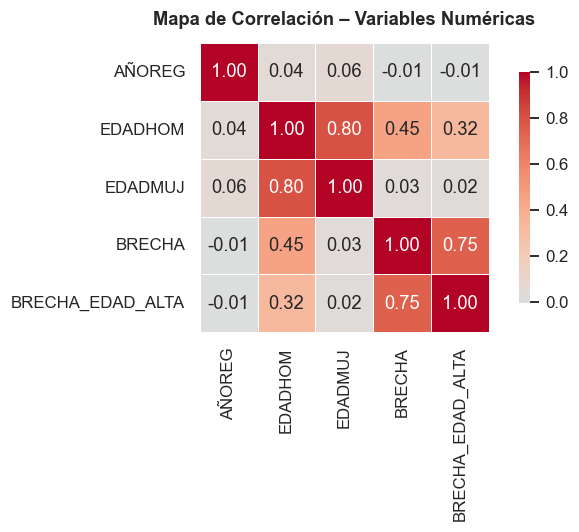

BRECHA tiene correlación perfecta con BRECHA_EDAD_ALTA (es su fuente directa).
EDADHOM y EDADMUJ tienen correlación positiva entre sí, lo esperado en parejas.
AÑOREG tiene correlación baja con las edades, indicando cambios generacionales leves.


In [13]:
# Heatmap de correlación (solo columnas numéricas)
num_cols = ['AÑOREG', 'EDADHOM', 'EDADMUJ', 'BRECHA', 'BRECHA_EDAD_ALTA']
corr = df_clean[num_cols].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Mapa de Correlación – Variables Numéricas', fontweight='bold', pad=12)
plt.tight_layout()
plt.show()
print("BRECHA tiene correlación perfecta con BRECHA_EDAD_ALTA (es su fuente directa).")
print("EDADHOM y EDADMUJ tienen correlación positiva entre sí, lo esperado en parejas.")
print("AÑOREG tiene correlación baja con las edades, indicando cambios generacionales leves.")


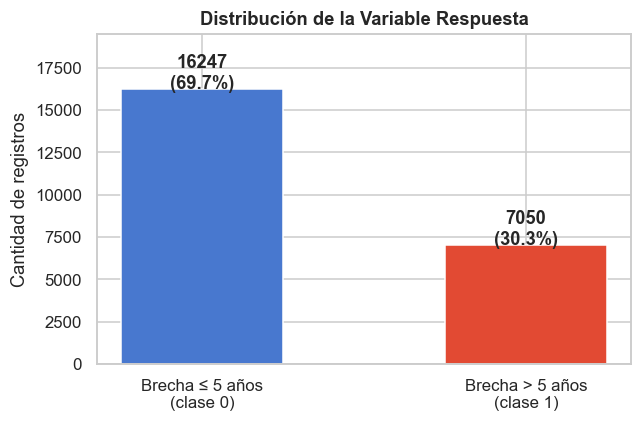

In [14]:
# Distribución de clases (gráfico de barras)
fig, ax = plt.subplots(figsize=(6, 4))
etiquetas = ['Brecha ≤ 5 años\n(clase 0)', 'Brecha > 5 años\n(clase 1)']
valores = df_clean['BRECHA_EDAD_ALTA'].value_counts().sort_index()
colores = ['#4878CF', '#E24A33']
bars = ax.bar(etiquetas, valores, color=colores, edgecolor='white', width=0.5)
for bar, val in zip(bars, valores):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 8,
            f'{val}\n({val/len(df_clean)*100:.1f}%)', ha='center', fontweight='bold')
ax.set_title('Distribución de la Variable Respuesta', fontweight='bold')
ax.set_ylabel('Cantidad de registros')
ax.set_ylim(0, max(valores) * 1.2)
plt.tight_layout()
plt.show()


## 5. Definición de Variables Predictoras y Respuesta

Se separan las variables en `X` (predictoras) e `y` (variable objetivo). El dataset codificado cuenta con **140 variables predictoras** tras aplicar One-Hot Encoding a `DEPOCU` (28 departamentos), `MESOCU` (12 meses), `NACHOM` (72 nacionalidades) y `NACMUJ` (55 nacionalidades), usando `drop_first=True` para evitar multicolinealidad.

Se mantienen `EDADHOM` y `EDADMUJ` como predictores individuales. La columna `BRECHA` se excluye de `X` para evitar *data leakage* directo: aunque es la fuente de la variable respuesta, incluirla haría el problema trivial y no generalizaría a datos nuevos donde la brecha podría no estar calculada de antemano.


In [15]:
# Variable respuesta
y = df_encoded['BRECHA_EDAD_ALTA']

# Variables predictoras (excluir target y BRECHA para evitar leakage directo)
X = df_encoded.drop(columns=['BRECHA_EDAD_ALTA'])

# También excluir BRECHA si existe en encoded (se calculó antes)
if 'BRECHA' in X.columns:
    X = X.drop(columns=['BRECHA'])

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"\nClases en y: {y.value_counts().to_dict()}")


X shape: (23297, 140)
y shape: (23297,)

Clases en y: {0: 16247, 1: 7050}


## 6. División en Conjuntos de Entrenamiento y Prueba (5)

Se usa `train_test_split` con los siguientes parámetros:

| Parámetro | Valor | Justificación |
|---|---|---|
| `test_size` | 0.20 | 80% entrenamiento / 20% prueba, proporción estándar en ML |
| `random_state` | 42 | Garantiza reproducibilidad de resultados |
| `stratify=y` | Variable respuesta | Mantiene la proporción de clases en ambas particiones |

Con el dataset completo, el split resultante es: **18,637 muestras en entrenamiento** y **4,660 en prueba**, ambos con la misma distribución de clases (69.74% clase 0 / 30.26% clase 1), confirmando que la estratificación funcionó correctamente.


In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

print(f"Conjunto de entrenamiento: {X_train.shape[0]} muestras ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Conjunto de prueba:        {X_test.shape[0]} muestras ({X_test.shape[0]/len(X)*100:.1f}%)")
print()
print("Proporción de clases en entrenamiento:")
print((y_train.value_counts(normalize=True)*100).round(2))
print()
print("Proporción de clases en prueba:")
print((y_test.value_counts(normalize=True)*100).round(2))


Conjunto de entrenamiento: 18637 muestras (80.0%)
Conjunto de prueba:        4660 muestras (20.0%)

Proporción de clases en entrenamiento:
BRECHA_EDAD_ALTA
0    69.74
1    30.26
Name: proportion, dtype: float64

Proporción de clases en prueba:
BRECHA_EDAD_ALTA
0    69.74
1    30.26
Name: proportion, dtype: float64


In [17]:
# Escalado para Regresión Logística (se crea una copia escalada)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("Escalado completado. Media ≈ 0, Desviación estándar ≈ 1 en X_train_scaled.")
print(f"   Media global: {X_train_scaled.mean():.4f}")
print(f"   Std global:   {X_train_scaled.std():.4f}")


Escalado completado. Media ≈ 0, Desviación estándar ≈ 1 en X_train_scaled.
   Media global: 0.0000
   Std global:   0.9673


## Función Auxiliar de Evaluación


In [18]:
#     Entrena y evalúa un modelo de clasificación binaria. Devuelve diccionario con métricas y opcionalmente grafica la matriz de confusión.
def evaluar_modelo(nombre, modelo, X_tr, X_te, y_tr, y_te, mostrar_matriz=True):
    modelo.fit(X_tr, y_tr)
    y_pred = modelo.predict(X_te)

    acc  = accuracy_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred, zero_division=0)
    rec  = recall_score(y_te, y_pred, zero_division=0)
    f1   = f1_score(y_te, y_pred, zero_division=0)

    if mostrar_matriz:
        cm = confusion_matrix(y_te, y_pred)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                      display_labels=['Brecha Baja (0)', 'Brecha Alta (1)'])
        fig, ax = plt.subplots(figsize=(5, 4))
        disp.plot(ax=ax, cmap='Blues', colorbar=False)
        ax.set_title(f'Matriz de Confusión\n{nombre}', fontweight='bold')
        plt.tight_layout()
        plt.show()
        print(classification_report(y_te, y_pred,
              target_names=['Brecha Baja (0)', 'Brecha Alta (1)']))

    return {'Modelo': nombre, 'Accuracy': acc, 'Precision': prec,
            'Recall': rec, 'F1': f1, 'objeto': modelo}

